# <b>1 | Reducing hospital readmissions</b>

## <b> 1.1 | Background</b>
I work for a consulting company helping a hospital group better understand patient readmissions. The hospital gave me access to ten years of information on patients readmitted to the hospital after being discharged. The doctors want you to assess if initial diagnoses, number of procedures, or other variables could help them better understand the probability of readmission. 

They want to focus follow-up calls and attention on those patients with a higher probability of readmission.

## <b>1.2 | The data</b>
You have access to ten years of patient information ([source](https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008)):

#### <b> 1.2.1 | Data description</b>
- "<mark>**age**</mark>" - age bracket of the patient
- "<mark>**time_in_hospital**</mark>" - days (from 1 to 14)
- "<mark>**n_procedures**</mark>" - number of procedures performed during the hospital stay
- "<mark>**n_lab_procedures**</mark>" - number of laboratory procedures performed during the hospital stay
- "<mark>**n_medications**</mark>" - number of medications administered during the hospital stay
- "<mark>**n_outpatient**</mark>" - number of outpatient visits in the year before a hospital stay
- "<mark>**n_inpatient**</mark>" - number of inpatient visits in the year before the hospital stay
- "<mark>**n_emergency**</mark>" - number of visits to the emergency room in the year before the hospital stay
- "<mark>**medical_specialty**</mark>" - the specialty of the admitting physician
- "<mark>**diag_1**</mark>" - primary diagnosis (Circulatory, Respiratory, Digestive, etc.)
- "<mark>**diag_2**</mark>" - secondary diagnosis
- "<mark>**diag_3**</mark>" - additional secondary diagnosis
- "<mark>**glucose_test**</mark>" - whether the glucose serum came out as high (> 200), normal, or not performed
- "<mark>**A1Ctest**</mark>" - whether the A1C level of the patient came out as high (> 7%), normal, or not performed
- "<mark>**change**</mark>" - whether there was a change in the diabetes medication ('yes' or 'no')
- "<mark>**diabetes_med**</mark>" - whether a diabetes medication was prescribed ('yes' or 'no')
- "<mark>**readmitted**</mark>" - if the patient was readmitted at the hospital ('yes' or 'no') 

***Acknowledgments**: Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records," BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.*

## 1.3 | Executive Summary

### 1.3.1 | Overview
This report aims to understand and reduce the readmition rate of a hospital group healthcare program

### 1.3.2 | The problem
There are three main things the hospital group focused their efforts trying to find a solution

1. What is the most common primary diagnosis by age group.
2. Some doctors believe diabetes might play a role in readmission. The effect of a diabetes diagnosis on readmission rates are going to be explored.
3. The groups of patients the hospital should focus their follow-up efforts in oder to better monitor patients with a high probability of readmission.

### 1.3.3 | How these problems were explored
In this report it is possible to find a solution for each of these problems
1. The most common primary diagnosis question was answered by dividing the data entries into age groups based on the `age` column of the `.csv` file. In that way it would be possible to plot and compare the different age groups and theira most common primary diagnosis. All of the ages were found to have "Circulatory" diagnosis as the most common one.
2. The effects of a diabetes diagnosis in the readmition rates were explored based on two ideas:
    <p>2.1 A single diagnosis in diabetes means the patient has diabetes, which allowed the merging of all patients with at least one diabetes diagnosis
    
    2.2 As the other diabetes related columns did not add any relevant information about the diabetes situation, the only columns used in the analysis were the diagnosis columns</p>
3. The most diverging features of the dataset were the age and diagnosis ones. So much that it was possible to evaluate the most prominent groups to be readmitted in the hospital. An EDA made it possible to conclude that elderly from 70 to 79 years of age with either respiratory or circulatory diagnosis were to be included in a follow-up routine, after leaving the hospital.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

patients = pd.read_csv('data/hospital_readmissions.csv')
display(patients.head())
patients.info()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

# <b>2 | Data manegment</b>

## <b>2.1 | Data types</b>
As the `.info()` method showed above, there are columns in the DataFrame that the DType should be different than the ones infered by pandas. The following changes could be applied:

- "**age**" - could be converted from **`object`** to **`category`**
- "**glucose_test**" - could be converted from **`object`** to **`bool`**
- "**A1Ctest**" - could be converted from **`object`** to **`bool`**
- "**change**" - could be converted from **`object`** to **`bool`**
- "**diabetes_med**" - could be converted from **`object`** to **`bool`**
- "**readmitted**" - could be converted from **`object`** to **`bool`**

These modifications are going to be of great use for exploring the data

In [2]:
# Create a list of Yes/No columns
yes_no = ['glucose_test',
          'A1Ctest',
          'change',
          'diabetes_med',
          'readmitted'
         ]

# Loop for each column
for col in yes_no:
    patients[col] = patients[col] == 'yes'

In [3]:
# Check all unique values in the age column
patients.age.unique()

array(['[70-80)', '[50-60)', '[60-70)', '[40-50)', '[80-90)', '[90-100)'],
      dtype=object)

In [4]:
# Change to categorical data type
patients['age'] = patients.age.astype('category')


## <b>2.3 | Remaining columns</b>
There are still 4 columns in the patients df that could be a different data type. Checking the unique values could help to determine wich is the best data type for each column.

In [5]:
# Print all the unique values for each remaining column
display(np.sort(patients.medical_specialty.unique()))
display(np.sort(patients.diag_1.unique()))
display(np.sort(patients.diag_2.unique()))
np.sort(patients.diag_3.unique())
patients['diag_1'] = patients.diag_1.astype('category')

array(['Cardiology', 'Emergency/Trauma', 'Family/GeneralPractice',
       'InternalMedicine', 'Missing', 'Other', 'Surgery'], dtype=object)

array(['Circulatory', 'Diabetes', 'Digestive', 'Injury', 'Missing',
       'Musculoskeletal', 'Other', 'Respiratory'], dtype=object)

array(['Circulatory', 'Diabetes', 'Digestive', 'Injury', 'Missing',
       'Musculoskeletal', 'Other', 'Respiratory'], dtype=object)

In [6]:
# Print all the unique values for each remaining column
diag_order = ['Circulatory',
              'Diabetes',
              'Digestive',
              'Injury',
              'Musculoskeletal',
              'Other',
              'Missing'
             ]

**As the code output has shown above, these columns could be set to `category` dtype. One other thing that could be percieved through the output is that the `"diag_n"` columns are three inputs of the same category for each patient, this will be observed and dealt with later on the report**

# 3 | Primary Diagnosis by age group

This section of the report aims to check and display the primary diagnosis distribution by age group

## 3.1 | Setting the Groups

This part will check weather or not the grouped data makes sense

In [7]:
# Group by age group and diagnosis

patients.groupby(['age'])['diag_1'].value_counts()

age       diag_1         
[40-50)   Other               750
          Circulatory         504
          Respiratory         376
          Diabetes            369
          Digestive           271
          Injury              162
          Musculoskeletal     100
          Missing               0
[50-60)   Circulatory        1256
          Other              1164
          Respiratory         694
          Digestive           442
          Diabetes            393
          Injury              273
          Musculoskeletal     230
          Missing               0
[60-70)   Circulatory        1962
          Other              1402
          Respiratory         836
          Digestive           554
          Injury              400
          Diabetes            385
          Musculoskeletal     373
          Missing               1
[70-80)   Circulatory        2392
          Other              1693
          Respiratory         964
          Digestive           585
          Injury      

## 3.2 | Display Information
In order to make the perception and analysis easier to understand. The graph shows how the primary diagnosis are distributed in each age group

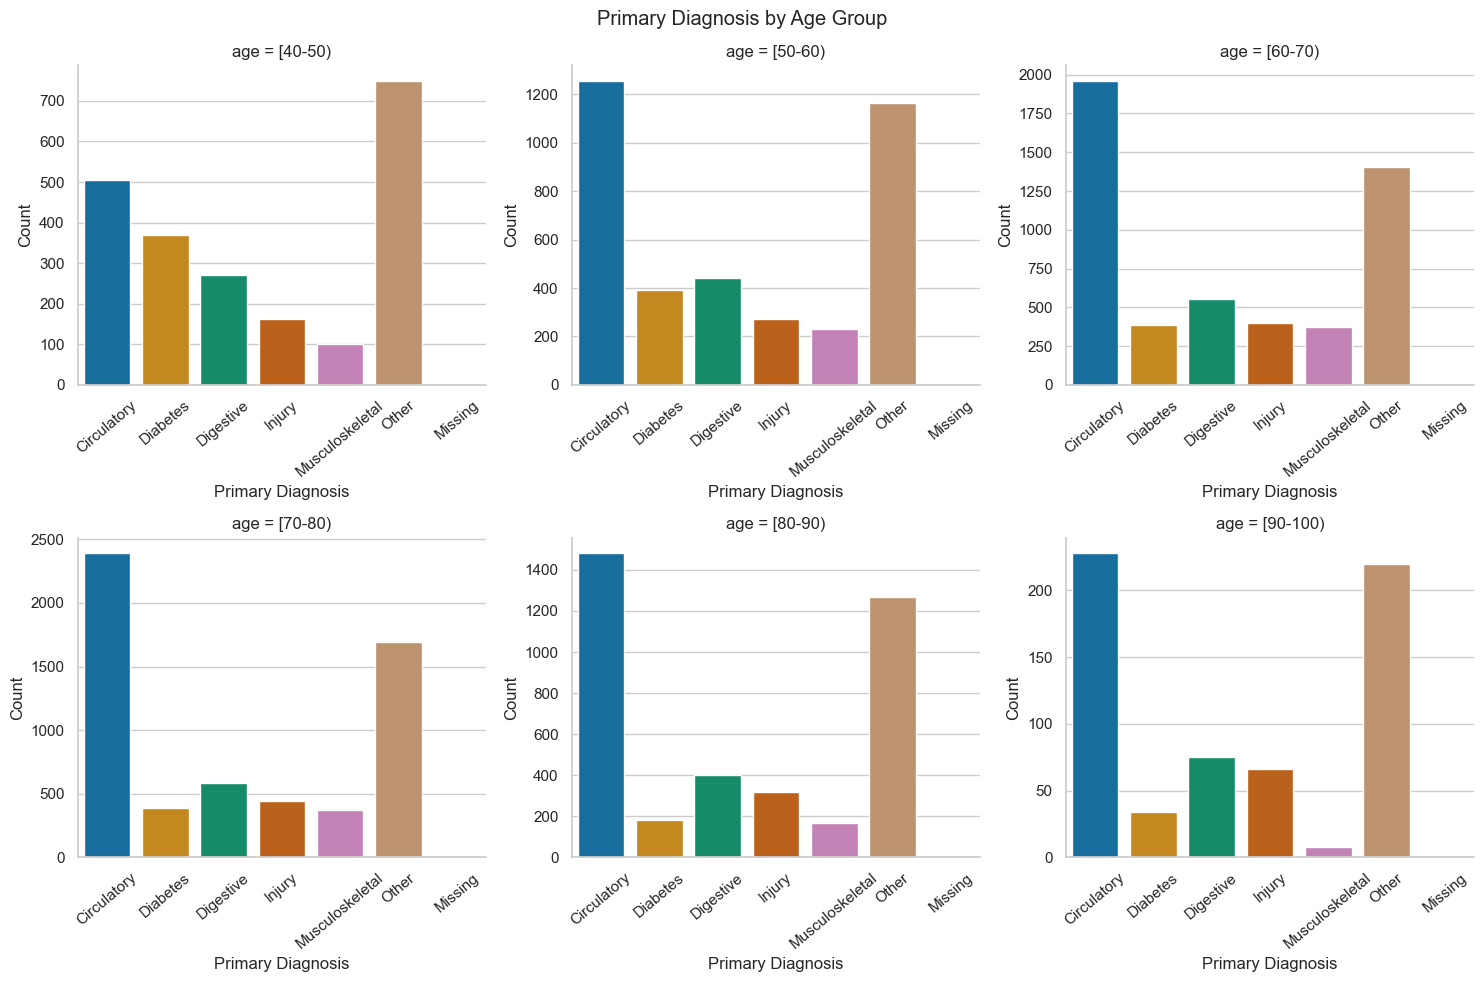

In [8]:
#Setting visualization style
sns.set_style('whitegrid')
sns.set_context('notebook')
sns.set_palette('colorblind')


#Plotting data
ax = sns.catplot(data=patients, 
                 x='diag_1',
                 kind='count',
                 col='age',
                 col_wrap=3,
                 sharex=False,
                 sharey=False,
                 order=diag_order
                )

#Setting axes title and rotation
ax.set_xticklabels(rotation=40)
ax.set(xlabel='Primary Diagnosis',ylabel='Count')
#Setting title and adjusting high
ax.fig.subplots_adjust(top=0.9)
ax.fig.suptitle('Primary Diagnosis by Age Group')

#Increasing distance inbetween rows
plt.tight_layout()
#Display the figure
plt.show()

## 3.3 | Conclusion
As shown in the image above, there is a trend in the Primary Diagnosis in all of the age groups.

**All** age groups have **"Circulatory"** as their most common Primary Diagnosis. The plots shown above show the blue bar, representing the amount of primary diagnosis being Circulatory, as the tallest one, except for the age group from **40 to 49 years**.

### Disclaimer
Even though the blue bar is not the tallest in the 40-49 age group, the largest bar is representing the **"Other"** category. This category is the sum of all the other possible Primary Diagnosis that where given in this age group. The **"Other"** bar should not be considered a single diagnosis, therefore not be considered as the most common one.


# 4 | The Effect of Diabetes Diagnosis on Readmission Rates
This section aims to check wheter or not diabetes plays a central role in readmission rates

## 4.1 | Explaining the approach
For this part of the report the **`pd.get_dummies`** is going to be used. This function transforms a category column, such as the **`diag_n`** columns, in a binary column, this approach makes handling with diabetes specific data.

In [9]:
patients_dummies = pd.get_dummies(patients, columns=['diag_1','diag_2','diag_3'])

### 4.1.1 | Diabetes Score
Based on the binary definition of the diabetes diagnosis, it is possible to set a new column called 'Diabetes Score', this will be used to compare the non-diabetes and diabetes diagnosis in order to figure out if a dianosis in diabetes has any influence in the readmission rate at this hospital

* **Diabetes Score** - the sum of binary columns in wich diabeses was the diagnosis given to the pacient. Interpret as follows
	- 0 - no diagnosis were "Diabetes"
	- 1 - one of three diagnosis was "Diabetes"
	- 2 - two of three diagnosis were "Diabetes"
	- 3 - all diagnosis were "Diabetes"

In [10]:
#Setting new column diabetes_score to groupby
patients_dummies['diabetes_score'] = patients_dummies[['diag_1_Diabetes',
                                                      'diag_2_Diabetes',
                                                      'diag_3_Diabetes']].sum(axis=1)

groupped_normalized = patients_dummies.groupby('diabetes_score')['readmitted'].value_counts(normalize=True)
groupped_unnormalized = patients_dummies.groupby('diabetes_score')['readmitted'].value_counts(normalize=False)

### 4.1.2 | Single Diagnosis

As diabetes is not an intermittent disease, it is possible to consider a person with more than one diagnois in the same group as a person with a single diabetes diagnosis. Therefore, people with a Diabetes Score, as explained above, with a value different than 0 are going to be groupped.

In [11]:
#Setting diabetes 1/0
patients_dummies['diabetes'] = patients_dummies['diabetes_score'].astype(bool)
patients_dummies['diabetes'] = patients_dummies['diabetes'].astype(int)

#Group by 'diabetes' and 'readmitted'
diabetes_group = patients_dummies.groupby('diabetes')['readmitted'].value_counts(normalize=True)
diabetes_group = diabetes_group.unstack()
diabetes_group.reset_index(inplace=True)
diabetes_group_reamitted = diabetes_group[True]

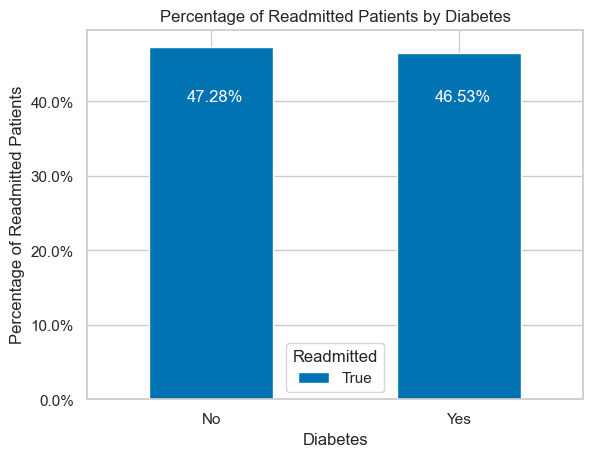

In [12]:
import matplotlib.ticker as mtick
ax = diabetes_group_reamitted.plot(kind='bar',
                             title ='Percentage of Readmitted Patients by Diabetes'
                             )
ax.set_ylabel('Percentage of Readmitted Patients')
ax.set_xlabel('Diabetes')
ax.set_xticklabels(['No','Yes'],rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.legend(title='Readmitted',loc='lower center')
ax.annotate('{:2.2%}'.format(diabetes_group_reamitted.iloc[0]),(-0.1,0.4),c='white')
ax.annotate('{:2.2%}'.format(diabetes_group_reamitted.iloc[1]),(0.9,0.4),c='white')
plt.show()

## 4.2 | Conclusion
With the analysis made in the previous block of this report, it is possible to conclude that a Diabetes diagnosis does not play central role in readmission rates at this hospital.

## 4.3 | Further Investigation
For the exposed question mora analysis will be necessary. The next section of this report aims to check what are the most influential characteristics in the readmission rates

# 5 | Follow-up groups

In order to reduce the readmission rates a follow-up routine should be implemented in the hospital. Some groups have a greater probability of readmission than others, based on many features, such as age, primary diagnosis and any other feature registred in the data.

## 5.1 | Approach
For this problem, a Exploratory Data Analysis is going to be used. That way it is possible to observe relationship between the variables availabe in the dataset. The steps are going to follow this specific order:
1. Treat data to be able to visualize it
2. Analyse the relationships between variables
3. Focus on the strongest relationships
4. Come up with a possible solution to the readmission rate problem

## 5.2 | Cleaning  data
For this approach a clean dataset will be necessary. For that matter all dtypes shall be either `category`, `numerical values` or `boolean`.

This will allow for a better analysis in a visual manner.

In [13]:
patients['diag_2'] = patients.diag_2.astype('category')
patients['diag_3'] = patients.diag_3.astype('category')
patients['medical_specialty'] = patients.medical_specialty.astype('category')
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   age                25000 non-null  category
 1   time_in_hospital   25000 non-null  int64   
 2   n_lab_procedures   25000 non-null  int64   
 3   n_procedures       25000 non-null  int64   
 4   n_medications      25000 non-null  int64   
 5   n_outpatient       25000 non-null  int64   
 6   n_inpatient        25000 non-null  int64   
 7   n_emergency        25000 non-null  int64   
 8   medical_specialty  25000 non-null  category
 9   diag_1             25000 non-null  category
 10  diag_2             25000 non-null  category
 11  diag_3             25000 non-null  category
 12  glucose_test       25000 non-null  bool    
 13  A1Ctest            25000 non-null  bool    
 14  change             25000 non-null  bool    
 15  diabetes_med       25000 non-null  bool    
 16  read

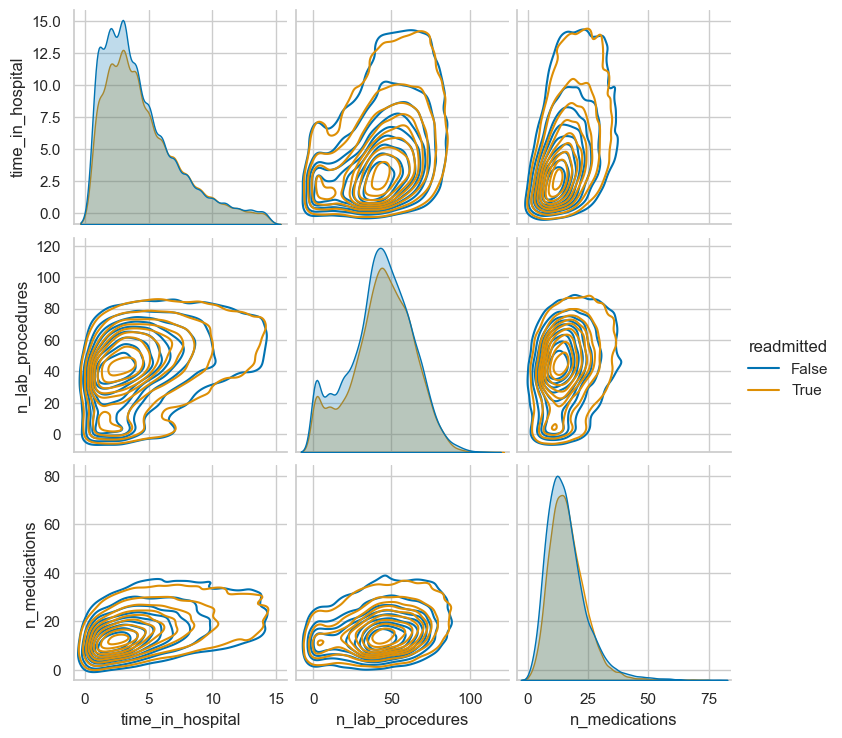

In [14]:
patients_numbers = patients[
    ['age',
     'time_in_hospital',
     'n_lab_procedures',
     'n_medications',
     'readmitted'
    ]
]

patients_categorical = patients[
    ['age',
     'medical_specialty',
     'diag_1',
     'diag_2',
     'diag_3',
     'glucose_test',
     'A1Ctest',
     'change',
     'diabetes_med',
     'readmitted'        
    ]
]
sns.pairplot(data=patients_numbers, hue='readmitted', kind='kde')
plt.show()

These KDE plots show that there is no noticeable relationship between the readmition rate and these numerical features

In [15]:
patients_categorical.describe()

,age,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,6,7,8,8,8,1,1,2,2,2
top,[70-80),Missing,Circulatory,Other,Other,False,False,False,True,False
freq,6837,12382,7824,9056,9107,25000,25000,13497,19228,13246


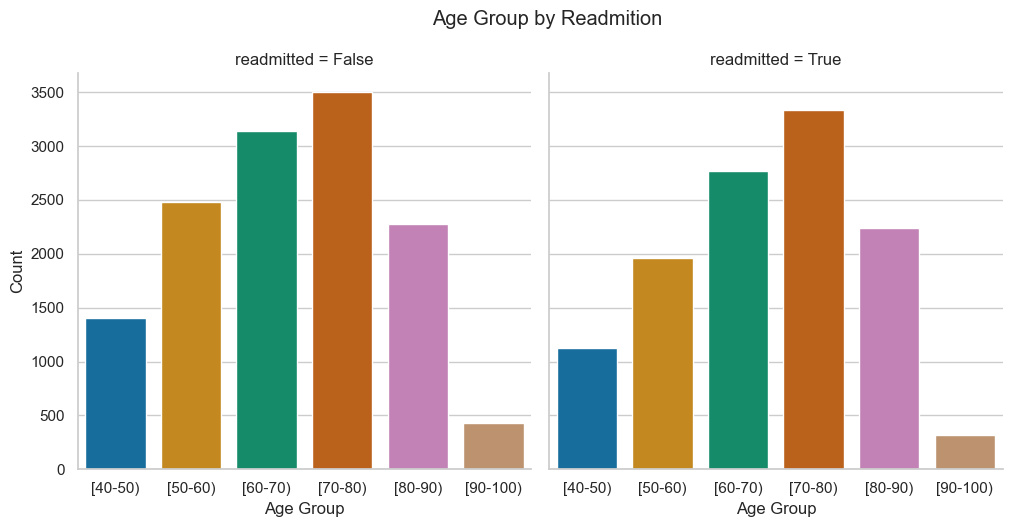

In [16]:
ax = sns.catplot(data=patients, 
                 x='age',
                 kind='count',
                 col='readmitted',
                 col_wrap=3,
                 sharex=True,
                 sharey=True,
                )

#Setting axes title and rotation
ax.set_xticklabels(rotation=0)
ax.set(xlabel='Age Group',ylabel='Count')
#Setting title and adjusting high
ax.fig.suptitle('Age Group by Readmition',x=0.37,y=1.05)

plt.show()

In [17]:
#Diagnosis groupped
readmitted_1= patients.groupby('age')[['diag_1','readmitted']].value_counts(normalize=False).unstack()
readmitted_2 = patients.groupby('age')['diag_2','readmitted'].value_counts(normalize=False).unstack()
readmitted_3 = patients.groupby('age')['diag_3','readmitted'].value_counts(normalize=False).unstack()
readmitted_t = readmitted_1 + readmitted_2 + readmitted_3

In [18]:
readmitted_t.unstack()
readmitted_t.reset_index(inplace=True)

In [19]:
readmitted_t.columns = ['age','diag','False','True']
melted = pd.melt(readmitted_t, id_vars=['age','diag'],value_vars=['False','True'], value_name='count',var_name='readmitted')

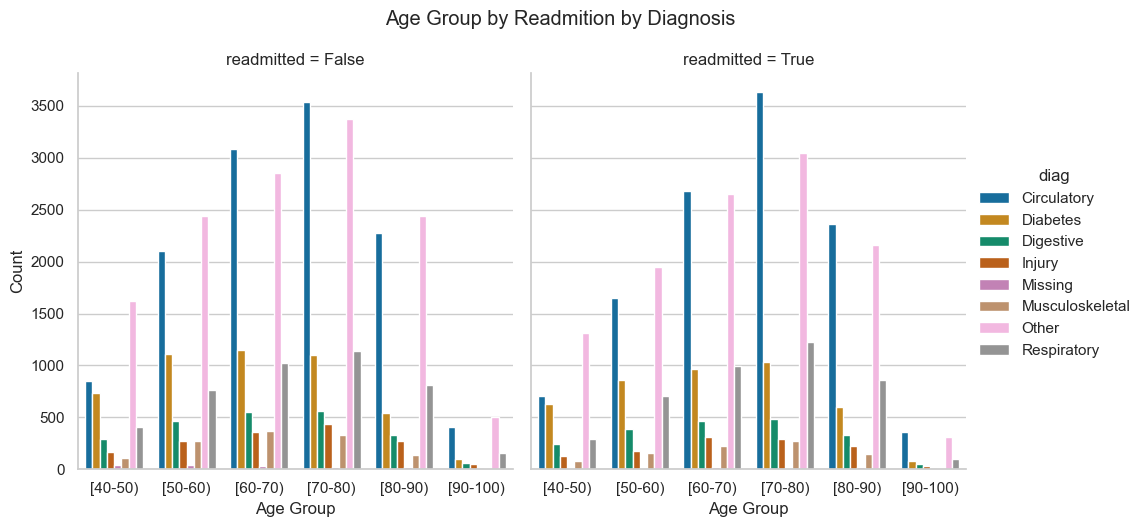

In [20]:
ax = sns.catplot(data=melted,
           x='age',
           hue='diag',
           y='count',
           col='readmitted',
           kind='bar',
            sharey=True
           )
#Setting axes title and rotation
ax.set(xlabel='Age Group',ylabel='Count')
#Setting title and adjusting high
ax.fig.suptitle('Age Group by Readmition by Diagnosis',x=0.5,y=1.05)

plt.show()

In [21]:
diag_list = melted['diag'].unique().categories.tolist()
if 'Missing' in diag_list:
    diag_list.remove('Missing')
if 'Other' in diag_list:
    diag_list.remove('Other')

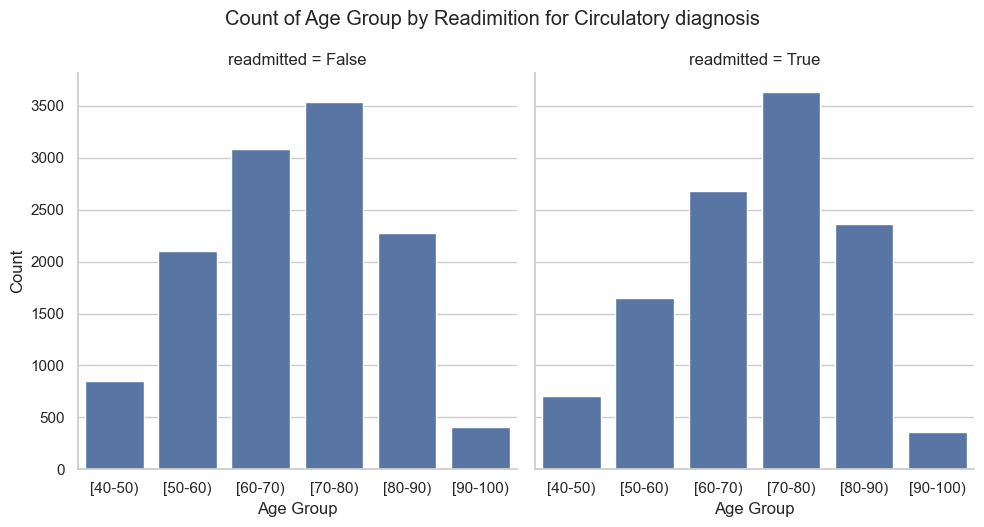

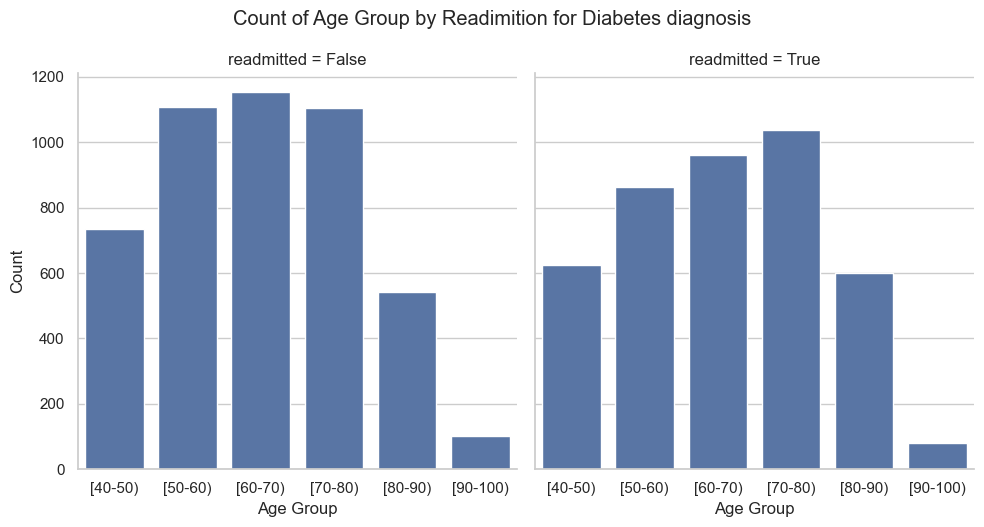

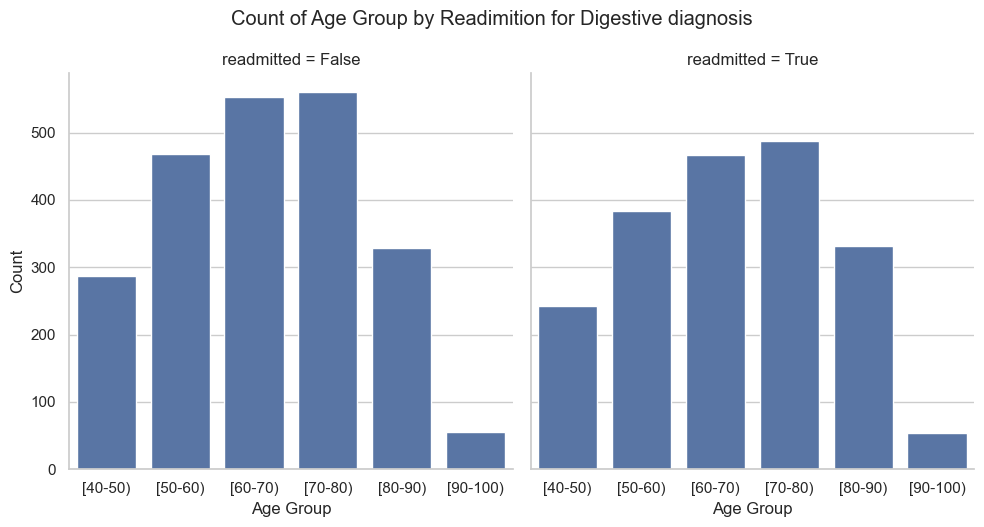

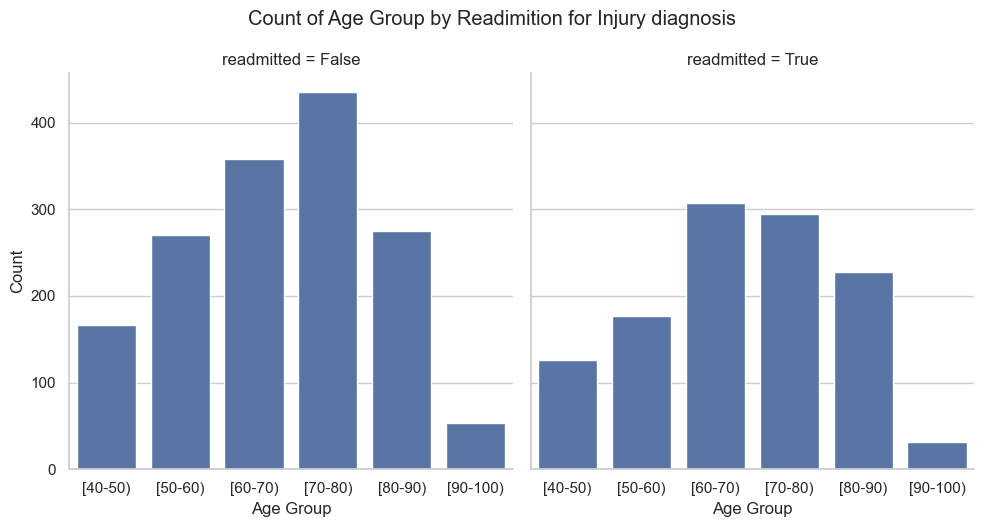

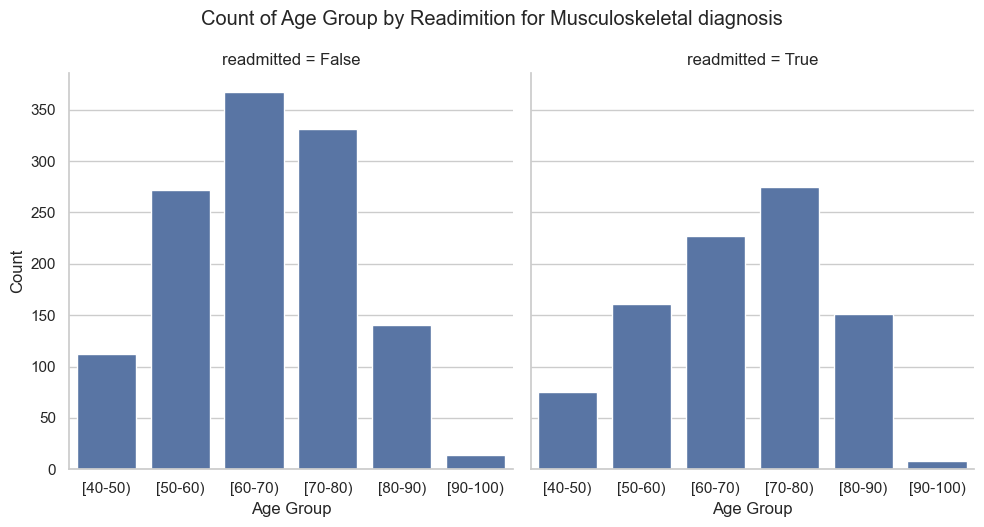

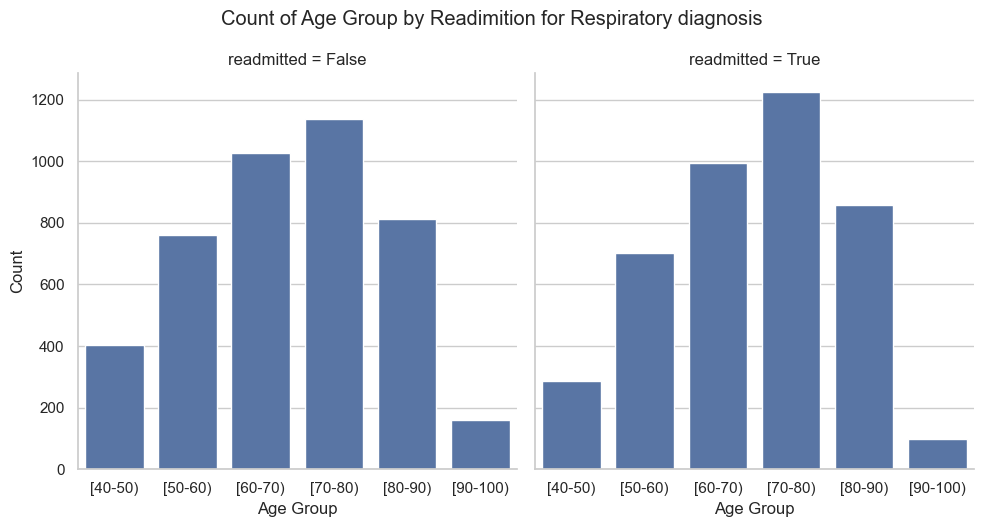

In [22]:
for diag in diag_list:
    ax = sns.catplot(data=melted[melted['diag']==diag],
           x='age',
           y='count',
           col='readmitted',
           kind='bar',
            sharey=True,
            color='b'
           )
    #Setting axes title and rotation
    ax.set(xlabel='Age Group',ylabel='Count')
    #Setting title and adjusting high
    ax.fig.suptitle(f'Count of Age Group by Readimition for {diag} diagnosis',x=0.5,y=1.05)

    plt.show()

## 5.3 | Conclusion
The plots show how the age groups and diagonis given to the patients influentiate the readmition rate of these patients.
For this specific case, the age group from **70 to 79** has shown the biggest growth in readmition rate for both the **Circulatory** and **Respiratory** diagnoses.

## 5.4 | Call to action
As stated a follow-up routine could have the best results in decresing readmition rates on from 70 to 79 with either circulatory or respiratory diseases.